# Using NSE protons

In [1]:
import pynucastro as pyna

In [2]:
nuclei = ["p", "n",
          "he4", "c12", "o16", "ne20", "mg24", "si28", "s32",
          "ar36", "ca40", "ti44", "cr48", "fe52", "ni56",
          "al27", "p31", "cl35", "k39", "sc43", "v47", "mn51", "co55",
          "n13", "na23",
          "fe53", "fe54", "fe55", "fe56",
          "co55", "co56", "co57", "ni56", "ni57", "ni58", "cu59", "zn60"]

In [3]:
net = pyna.network_helper(nuclei)

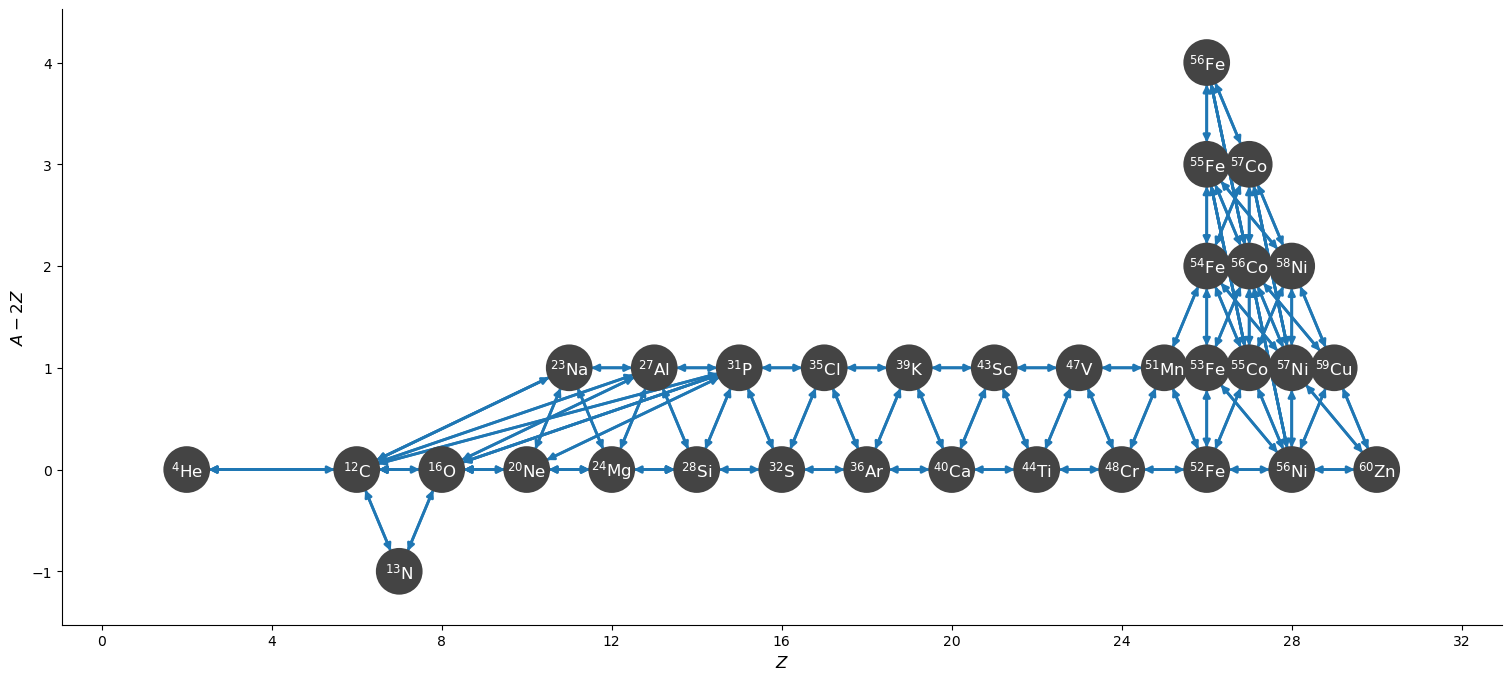

In [4]:
fig = net.plot(rotated=True, size=(1500, 700))

In [5]:
net.make_ap_pg_approx(intermediate_nuclei=["cl35", "k39", "sc43", "v47"])
net.remove_nuclei(["cl35", "k39", "sc43", "v47"])

In [6]:
net.make_nn_g_approx(intermediate_nuclei=["fe53", "fe55", "ni57"])
net.remove_nuclei(["fe53", "fe55", "ni57"])

## remove light n-capture rates

In [7]:
rates_to_remove = []
A_max = 48
for r in net.get_rates():
    all_nuc = set(r.reactants + r.products)
    if pyna.Nucleus("n") in all_nuc and 1 < max(all_nuc).A < A_max:
        rates_to_remove.append(r)
               

In [8]:
rates_to_remove

[]

In [9]:
net.remove_rates(rates_to_remove)

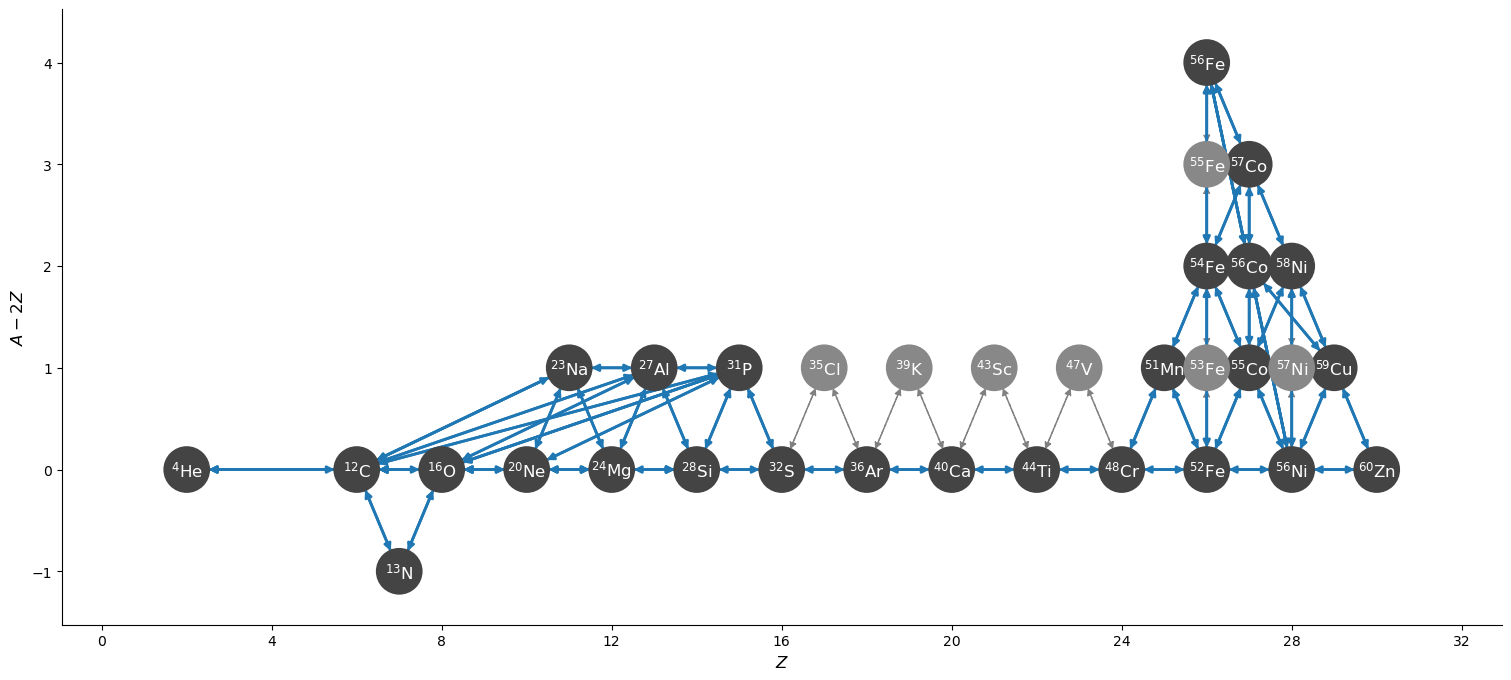

In [10]:
fig = net.plot(rotated=True, size=(1500, 700))

## Integrate the network

In [11]:
rho = 1.e8
T = 4.e9
comp = pyna.Composition(net.unique_nuclei, small=0.0)
comp.X[pyna.Nucleus("he4")] = 1.0

In [12]:
tmax = 100

In [13]:
atol = 1.e-10

In [14]:
sol = net.integrate_network(tmax, rho, T, comp.get_molar_array(), atol=atol)

/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: C12 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: N13 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))


/home/zingale/development/pynucastro/pynucastro/networks/python_network.py:412: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(tmin, tmax)


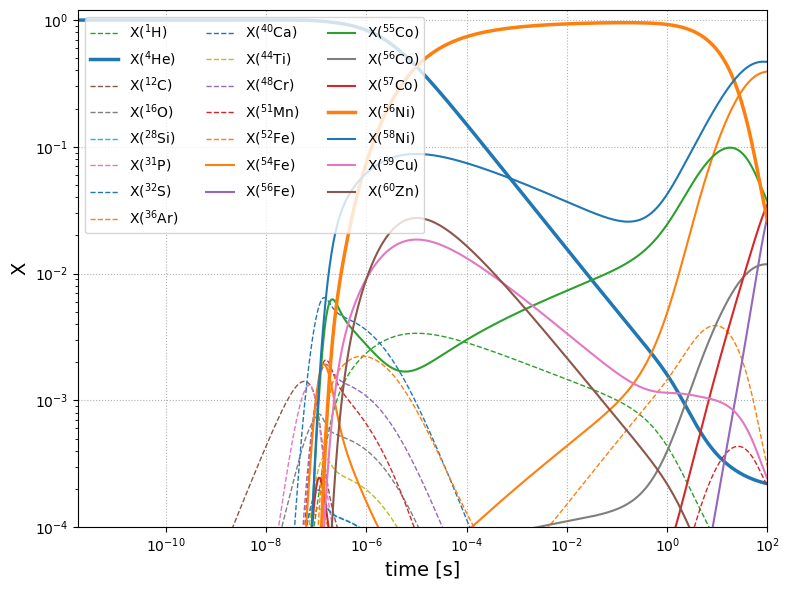

In [15]:
fig = sol.plot_evolution(three_level_style=True, ymin=1.e-4)

## Now create a network with protons split

In [16]:
net_approx = pyna.PythonNetwork(rates=net.get_rates())

In [17]:
net_approx.make_nse_protons(A_max)

In [18]:
comp_approx = pyna.Composition(net_approx.unique_nuclei, small=0.0)
comp_approx.X[pyna.Nucleus("he4")] = 1.0

In [19]:
sol_approx = net_approx.integrate_network(tmax, rho, T, comp_approx.get_molar_array(), atol=atol)

/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: C12 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: N13 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))


In [20]:
sol_approx.success

True

In [21]:
import matplotlib.pyplot as plt

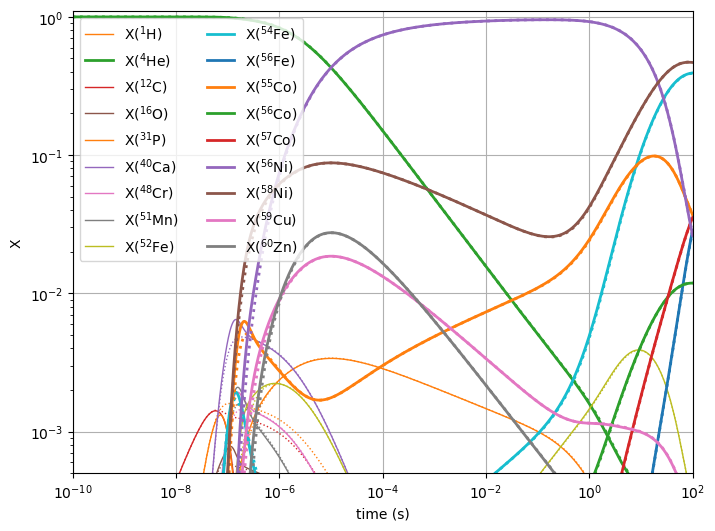

In [22]:
fig, ax = plt.subplots()
ymin = 5.e-4

for i, nuc in enumerate(sol.unique_nuclei):
    max_X = sol.X[i, :].max()
    
    lw = 1
    if max_X > 1.e-2:
        lw = 2
    if max_X < ymin:
        continue

    ax.loglog(sol.t, sol.X[i, :],
              label=rf"X$({nuc.pretty})$",              
              linestyle="-", color=f"C{i}", lw=lw)

    idx = sol_approx.unique_nuclei.index(nuc)
    X = sol_approx.X[idx, :]
    
    # add p and p_nse when we encounter p
    if nuc == pyna.Nucleus("p"):
        idx2 = sol_approx.unique_nuclei.index(pyna.Nucleus("p_nse"))
        X += sol_approx.X[idx2, :]
        
    ax.loglog(sol_approx.t, X,
              linestyle=":", color=f"C{i}", lw=lw)    

ax.set_ylim(ymin, 1.1)
ax.set_xlim(1.e-10, 100)
fig.set_size_inches((8,6))
ax.set_xlabel("time (s)")
ax.set_ylabel("X")
ax.legend(ncol=2)
ax.grid()

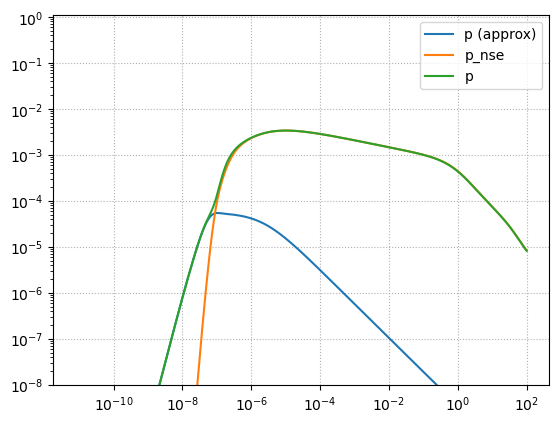

In [23]:
fig, ax = plt.subplots()

ip_approx = sol_approx.unique_nuclei.index(pyna.Nucleus("p"))
ipnse_approx = sol_approx.unique_nuclei.index(pyna.Nucleus("p_nse"))

ax.loglog(sol_approx.t, sol_approx.X[ip_approx, :], label="p (approx)")
ax.loglog(sol_approx.t, sol_approx.X[ipnse_approx, :], label="p_nse")

ip = sol.unique_nuclei.index(pyna.Nucleus("p"))

ax.loglog(sol.t, sol.X[ip, :], label="p")

ax.set_ylim(1.e-8, 1.1)
ax.legend()

ax.grid(ls=":")

## Difference plot

In [24]:
import numpy as np

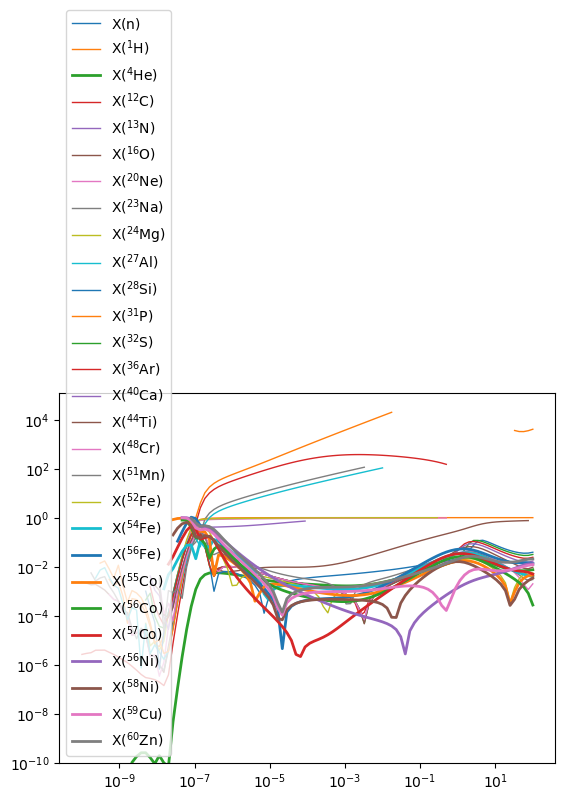

In [29]:
ts = np.logspace(-10, 2, 100)

fig, ax = plt.subplots()

for i, nuc in enumerate(sol.unique_nuclei):
    idx = sol_approx.unique_nuclei.index(nuc)

    X = sol.X_at(ts)[i, :]
    lw = 1
    if X.max() > 1.e-2:
        lw = 2
    X_approx = sol_approx.X_at(ts)[idx, :]

    err = np.abs(X - X_approx)
    err = np.where(X > atol, err, np.nan)
    
    ax.loglog(ts, err / X, label=rf"X$({nuc.pretty})$", lw=lw)

ax.set_ylim(1.e-10)
ax.legend()

In [26]:
sol_approx.X_at([1]).shape

(29, 1)